In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
table_3 = pd.read_csv("Table_3_v2.txt")

In [4]:
import numpy as np

def read_table_simple(fname):
    table = {}

    with open(fname) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            t = line.split()

            # Header rows
            if t[0] in ("ro_ddt", "Z"):
                table[t[0]] = np.array(t[1:], float)

            # Element rows
            elif t[0] == "elem":
                name = f"{t[2]}"          # e.g. "He", "C"
                table[name] = np.array(t[4:], float)

            # Isotope rows
            elif t[0] == "isot":
                name = f"{t[2]}{t[3]}"    # e.g. "He3", "He4"
                table[name] = np.array(t[4:], float)

    return table


In [5]:
table = read_table_simple("Table_3_v2.txt")

In [7]:
table_3 = pd.read_csv("Table_3_no_header.txt")

In [8]:
table_3

,ro_ddt 1.2E+07 1.2E+07 1.2E+07 1.2E+07 1.2E+07 1.6E+07 1.6E+07 1.6E+07 1.6E+07 1.6E+07 2.4E+07 2.4E+07 2.4E+07 2.4E+07 2.4E+07 2.8E+07 2.8E+07 2.8E+07 2.8E+07 2.8E+07 4.0E+07 4.0E+07 4.0E+07 4.0E+07 4.0E+07
0,Z 2.25E-4 2.25E-3 9.00E-3 2.2...
1,elem 2 He 2 3.01E-04 2.87E-04 2.57E-04 1.61...
2,isot 2 He 3 1.58E-12 1.56E-12 1.54E-12 1.42...
3,isot 2 He 4 3.01E-04 2.87E-04 2.57E-04 1.61...
4,elem 6 C 2 4.94E-03 4.98E-03 4.90E-03 5.06...
...,...
114,elem 35 Br 1 7.46E-11 3.00E-09 3.49E-08 5.25...
115,isot 35 Br 79 7.46E-11 3.00E-09 3.49E-08 5.25...
116,elem 36 Kr 2 1.45E-09 5.53E-08 9.76E-07 7.40...
117,isot 36 Kr 78 1.29E-09 3.07E-08 2.06E-07 1.28...


In [12]:
import pandas as pd

# Read header rows separately
ro_ddt = pd.read_csv("Table_3_no_header.txt", sep=r"\s+", nrows=1, header=None).iloc[0,1:].astype(float).values
Z      = pd.read_csv("Table_3_no_header.txt", sep=r"\s+", skiprows=1, nrows=1, header=None).iloc[0,1:].astype(float).values

# Read remaining rows
df = pd.read_csv(
    "Table_3_no_header.txt",
    sep=r"\s+",
    skiprows=2,
    header=None
)

# Build column names
n_models = len(ro_ddt)
df.columns = ['elem_or_iso','A_or_Z','element','junk'] + [f'model_{i+1}' for i in range(n_models)]

# Drop unused metadata column
df = df.drop(columns='junk')


In [21]:
Mn_yields = df[(df['element'] == 'Mn') & (df['elem_or_iso'] == 'elem')]

Ni_yields = df[(df['element'] == 'Ni') & (df['elem_or_iso'] == 'elem')]

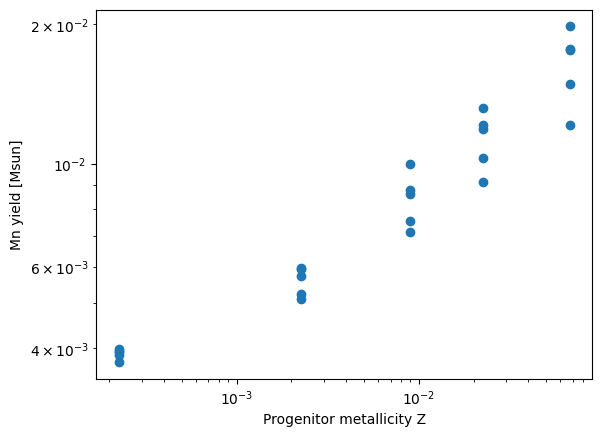

In [20]:
# Extract numeric values (skip metadata columns)
y = Mn_yields.iloc[0, 3:].to_numpy(dtype=float)

# Z already from earlier read
x = Z

plt.figure()
plt.scatter(x, y)
plt.xlabel("Progenitor metallicity Z")
plt.ylabel("Mn yield [Msun]")
plt.xscale("log")        # usually appropriate
plt.yscale("log")        # yields span orders of magnitude
plt.show()


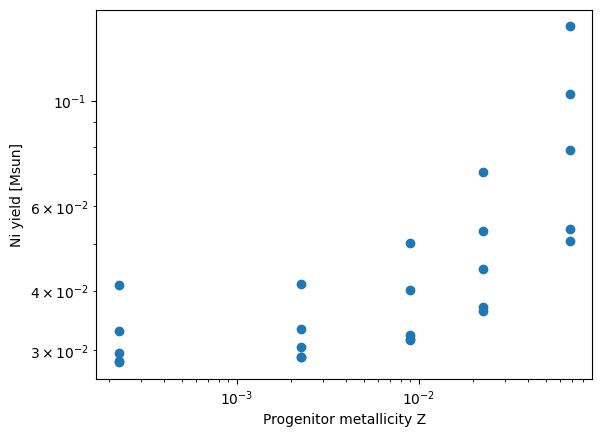

In [23]:
# Extract numeric values (skip metadata columns)
y = Ni_yields.iloc[0, 3:].to_numpy(dtype=float)

# Z already from earlier read
x = Z

plt.figure()
plt.scatter(x, y)
plt.xlabel("Progenitor metallicity Z")
plt.ylabel("Ni yield [Msun]")
plt.xscale("log")        # usually appropriate
plt.yscale("log")        # yields span orders of magnitude
plt.show()
